<a href="https://colab.research.google.com/github/AbhishekShah272002/Machine-Learning-Study./blob/main/Learning-Labs/Concrete_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_excel('Concrete_Data.xls')
display(df.head())

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   Cement (component 1)(kg in a m^3 mixture)              1030 non-null   float64
 1   Blast Furnace Slag (component 2)(kg in a m^3 mixture)  1030 non-null   float64
 2   Fly Ash (component 3)(kg in a m^3 mixture)             1030 non-null   float64
 3   Water  (component 4)(kg in a m^3 mixture)              1030 non-null   float64
 4   Superplasticizer (component 5)(kg in a m^3 mixture)    1030 non-null   float64
 5   Coarse Aggregate  (component 6)(kg in a m^3 mixture)   1030 non-null   float64
 6   Fine Aggregate (component 7)(kg in a m^3 mixture)      1030 non-null   float64
 7   Age (day)                                              1030 non-null   int64  
 8   Concrete compressive strength(MPa, megapascals)  

In [4]:
df.shape

(1030, 9)

### Finding the Interquartile Range (IQR)

The **Interquartile Range (IQR)** is a measure of statistical dispersion, or how spread out the middle 50% of your data is. It's often used to identify outliers in a dataset.

Here's how to calculate it:
1.  **First Quartile (Q1):** This is the 25th percentile of the data, meaning 25% of the data falls below this value.
2.  **Third Quartile (Q3):** This is the 75th percentile of the data, meaning 75% of the data falls below this value.
3.  **IQR Calculation:** IQR = Q3 - Q1

I will now calculate the IQR for each numerical column in your DataFrame.

In [7]:
# Select only numerical columns for IQR calculation
numerical_cols = df.select_dtypes(include=np.number).columns

# Calculate Q1 (25th percentile) and Q3 (75th percentile) for each numerical column
Q1 = df[numerical_cols].quantile(0.25)
Q3 = df[numerical_cols].quantile(0.75)

# Calculate the IQR
IQR = Q3 - Q1

print("Interquartile Range (IQR) for each numerical column:")
display(IQR)

Interquartile Range (IQR) for each numerical column:


,0
Cement (component 1)(kg in a m^3 mixture),157.625000
Blast Furnace Slag (component 2)(kg in a m^3 mixture),142.950000
Fly Ash (component 3)(kg in a m^3 mixture),118.270000
Water (component 4)(kg in a m^3 mixture),27.100000
Superplasticizer (component 5)(kg in a m^3 mixture),10.160000
Coarse Aggregate (component 6)(kg in a m^3 mixture),97.400000
Fine Aggregate (component 7)(kg in a m^3 mixture),93.050000
Age (day),49.000000
"Concrete compressive strength(MPa, megapascals)",22.429171


### Box Plots for Each Numerical Feature

Box plots are excellent for visualizing the distribution of a numerical variable and detecting outliers. The box represents the interquartile range (IQR), with the median marked inside. The 'whiskers' extend to 1.5 times the IQR from the quartiles, and points beyond the whiskers are considered outliers.

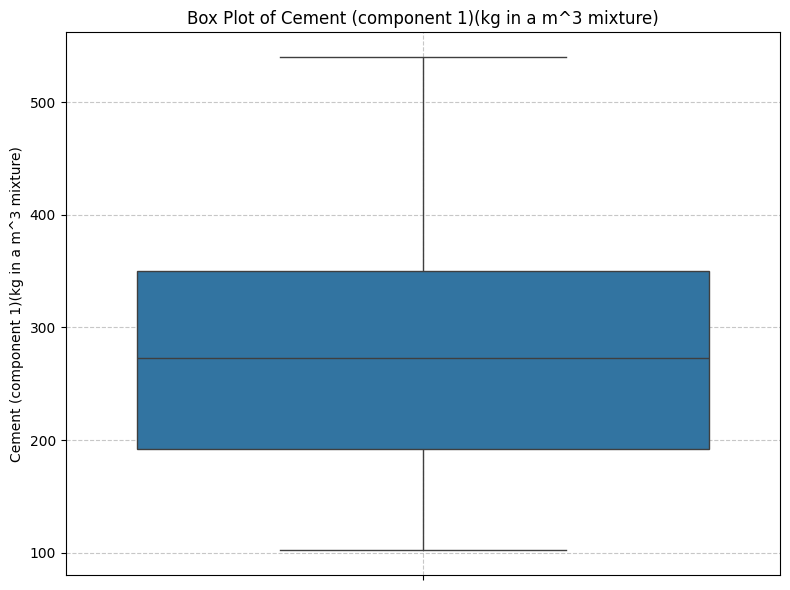

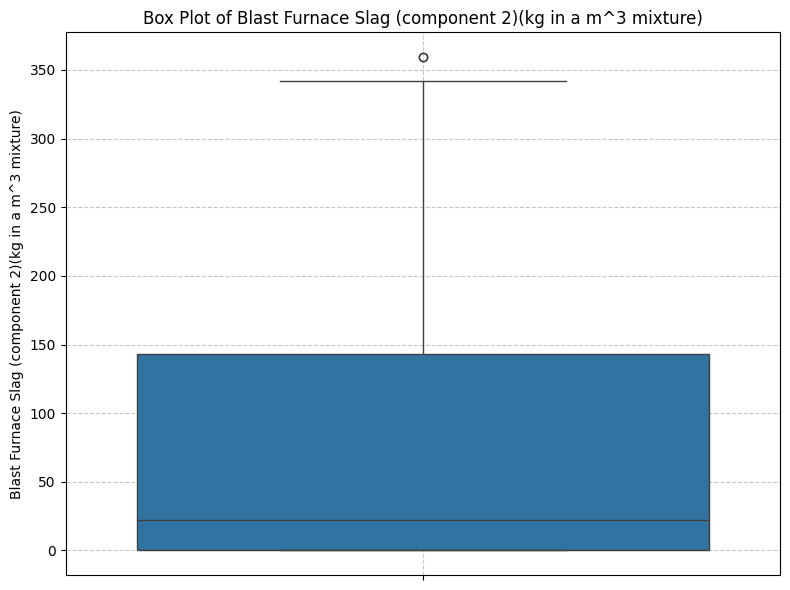

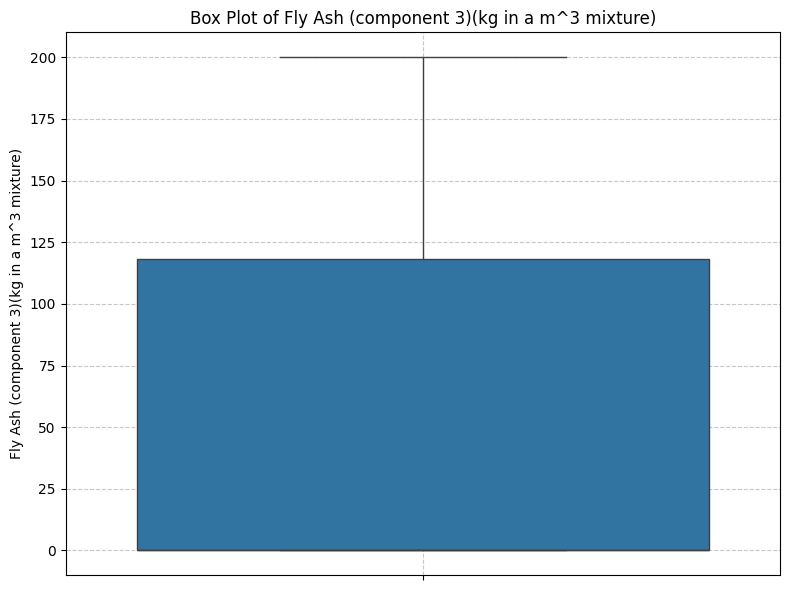

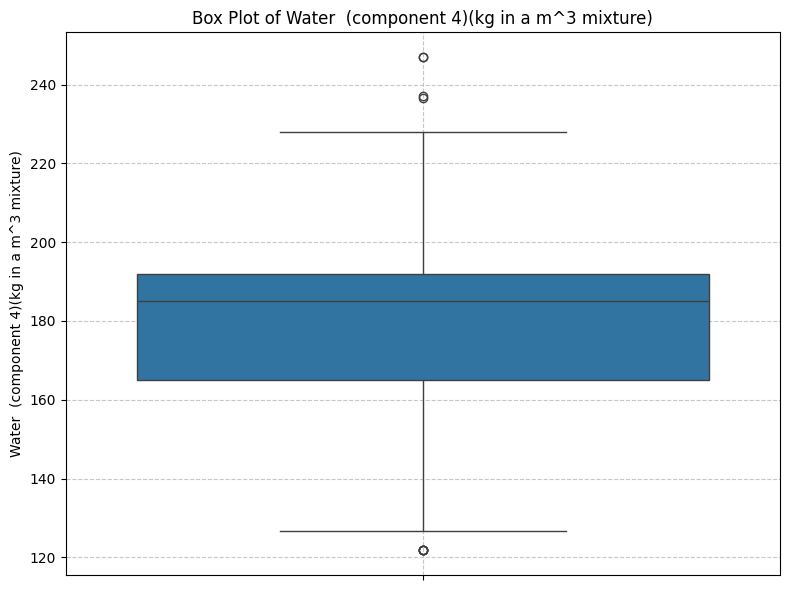

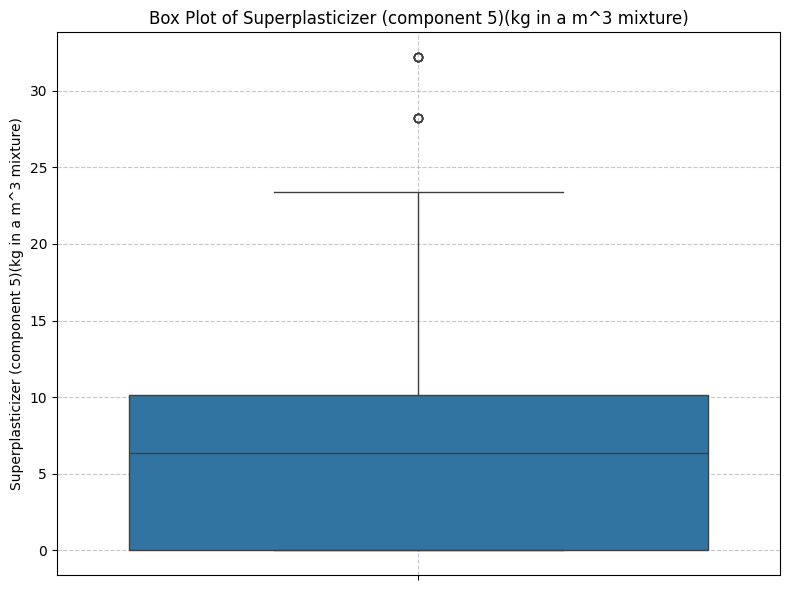

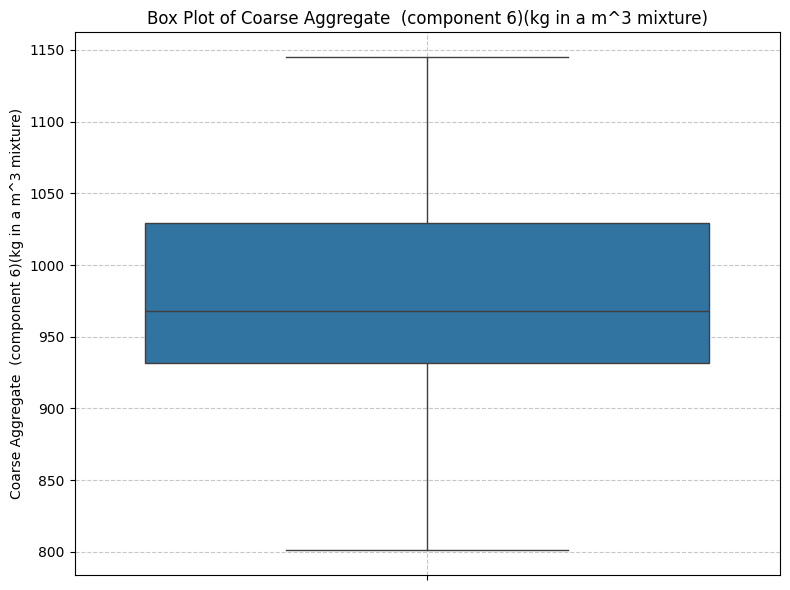

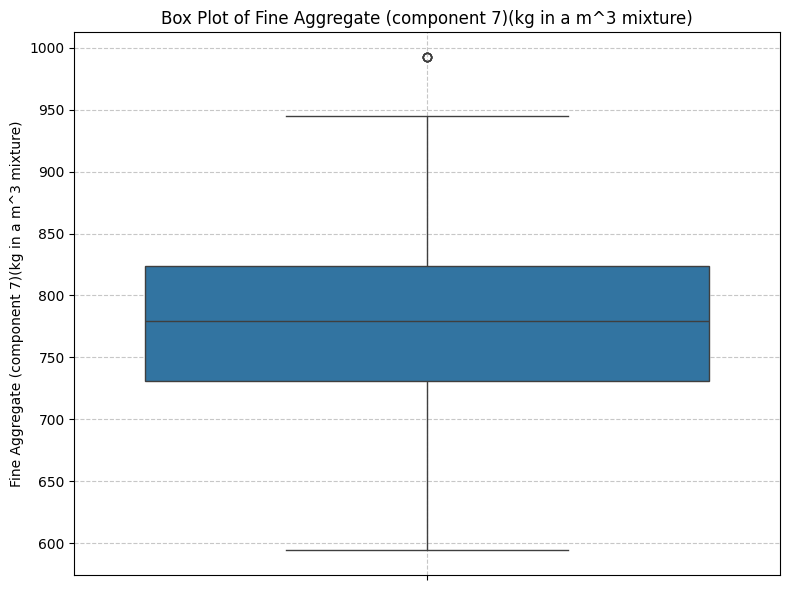

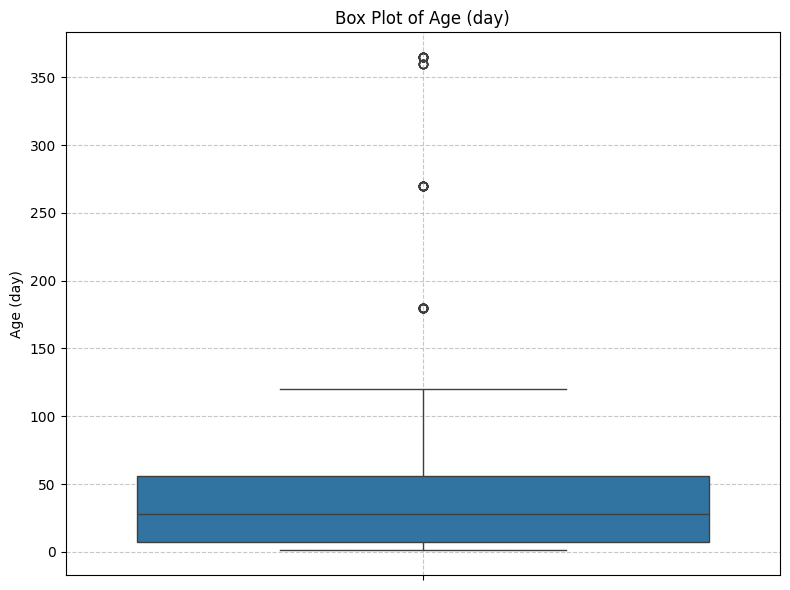

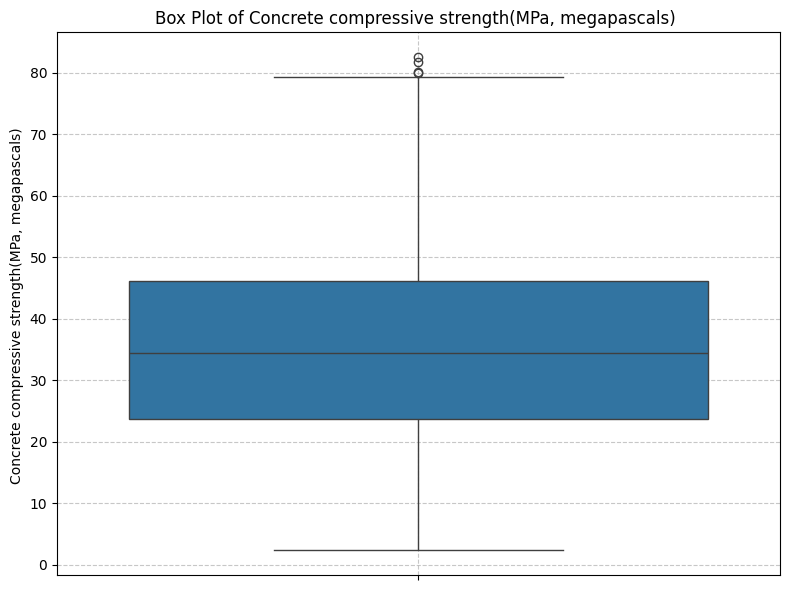

In [8]:
# Get all numerical columns for plotting box plots
numerical_cols = df.select_dtypes(include=np.number).columns

# Create a box plot for each numerical column
for column in numerical_cols:
    plt.figure(figsize=(8, 6)) # Set a good figure size for each plot
    sns.boxplot(y=df[column])
    plt.title(f'Box Plot of {column}') # Add title for clarity
    plt.ylabel(column) # Add y-axis label
    plt.grid(True, linestyle='--', alpha=0.7) # Add a grid for readability
    plt.tight_layout() # Adjust layout to prevent labels from being cut off
    plt.show() # Display the plot